In [3]:
import pandas as pd

PROBE_ROWS_PATH = "probe_results_rows.csv"
TOPUP_ROWS_PATH = "probe_results_topup_rows.csv"

OUT_SPLIT_PROBE_PATH = "probe_results_rows_split_from_topup_start.csv"
OUT_COMBINED_PATH = "probe_results_combined_from_topup_start.csv"
OUT_CAPPED_PATH = "probe_results_combined_from_topup_start_capped_4perhour.csv"

TIME_COL_CANDIDATES = ["start_time_utc", "timestamp", "time", "created_at", "start_time", "ts"]

POOL_COL_CANDIDATES = [
    ["pool"],
    ["provider", "region", "instance_type"],
]

MAX_PER_HOUR_PER_POOL = 4


def pick_existing_col(df: pd.DataFrame, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    raise KeyError(
        f"Could not find a timestamp column. Tried {candidates}. "
        f"Found columns: {sorted(df.columns)}"
    )

def pick_pool_cols(df: pd.DataFrame):
    cols = set(df.columns)
    for group in POOL_COL_CANDIDATES:
        if all(c in cols for c in group):
            return group
    raise KeyError(
        f"Could not find pool columns. Tried groups: {POOL_COL_CANDIDATES}. "
        f"Found columns: {sorted(df.columns)}"
    )

def robust_parse_utc_series(s: pd.Series) -> pd.Series:
    s = s.astype("string")

    dt = pd.to_datetime(s, utc=True, errors="coerce")

    if dt.isna().any():
        m = dt.isna()
        dt2 = pd.to_datetime(s[m].str.strip(), utc=True, errors="coerce")
        dt.loc[m] = dt2

    if dt.isna().any():
        m = dt.isna()
        s3 = s[m].str.strip()
        s3 = s3.str.replace(r"\s+UTC$", "+00:00", regex=True)
        s3 = s3.str.replace(r"(\+\d{2})$", r"\1:00", regex=True)
        dt3 = pd.to_datetime(s3, utc=True, errors="coerce")
        dt.loc[m] = dt3

    return dt

def drop_bad_time_rows(df: pd.DataFrame, time_col: str, name: str) -> pd.DataFrame:
    bad = df[time_col].isna()
    n_bad = int(bad.sum())
    if n_bad:
        examples = df.loc[bad, time_col].head(10).astype("string").tolist()
        print(f"⚠️ {name}: dropping {n_bad} rows with unparseable timestamps in '{time_col}'.")
        print(f"   Examples (first 10): {examples}")
        df = df.loc[~bad].copy()
    return df

def print_time_summary(df: pd.DataFrame, time_col: str, name: str):
    if len(df) == 0:
        print(f"{name}: EMPTY")
        return
    print(
        f"{name}: rows={len(df):,} | "
        f"start={df[time_col].min()} | "
        f"end={df[time_col].max()}"
    )

probe = pd.read_csv(PROBE_ROWS_PATH)
topup = pd.read_csv(TOPUP_ROWS_PATH)

time_col_probe = pick_existing_col(probe, TIME_COL_CANDIDATES)
time_col_topup = pick_existing_col(topup, TIME_COL_CANDIDATES)

probe[time_col_probe] = robust_parse_utc_series(probe[time_col_probe])
probe = drop_bad_time_rows(probe, time_col_probe, "probe_results_rows")

topup[time_col_topup] = robust_parse_utc_series(topup[time_col_topup])
topup = drop_bad_time_rows(topup, time_col_topup, "probe_results_topup_rows")

if time_col_topup != time_col_probe:
    topup = topup.rename(columns={time_col_topup: time_col_probe})

time_col = time_col_probe

probe = probe.sort_values(time_col, kind="mergesort").reset_index(drop=True)
topup = topup.sort_values(time_col, kind="mergesort").reset_index(drop=True)

if len(topup) == 0:
    raise ValueError("Topup file is empty after timestamp parsing, so no cutoff can be determined.")

topup_cutoff = topup[time_col].min()
print(f"\nUsing dynamic cutoff from FIRST topup row: {topup_cutoff}")

# Split original probe_results_rows so it starts at/after topup cutoff
probe_split = probe.loc[probe[time_col] >= topup_cutoff].copy().reset_index(drop=True)

if len(probe_split) == 0:
    raise ValueError(
        "After applying the cutoff, probe_split is empty. "
        "That means the original probe file has no rows at or after the first topup timestamp."
    )

common_start = probe_split[time_col].min()
print(f"Common enforced start time for all outputs: {common_start}")

probe_split = probe_split.loc[probe_split[time_col] >= common_start].copy().reset_index(drop=True)
probe_split.to_csv(OUT_SPLIT_PROBE_PATH, index=False)

print(f"✅ Saved split probe file: {OUT_SPLIT_PROBE_PATH}")
print_time_summary(probe_split, time_col, "probe_split")


combined = pd.concat([probe_split, topup], ignore_index=True)
combined = combined.sort_values(time_col, kind="mergesort").reset_index(drop=True)

# remove any earlier topup rows so combined starts exactly where probe_split starts
combined = combined.loc[combined[time_col] >= common_start].copy().reset_index(drop=True)

combined.to_csv(OUT_COMBINED_PATH, index=False)

print(f"✅ Saved combined file: {OUT_COMBINED_PATH}")
print_time_summary(combined, time_col, "combined")


# Cap combined to <=4 per pool per hour
pool_cols = pick_pool_cols(combined)

combined["_hour_bucket_utc"] = pd.to_datetime(combined[time_col], utc=True).dt.floor("h")

combined_capped = (
    combined
    .sort_values(time_col, kind="mergesort")
    .groupby(pool_cols + ["_hour_bucket_utc"], sort=False, as_index=False)
    .head(MAX_PER_HOUR_PER_POOL)
    .drop(columns=["_hour_bucket_utc"])
    .reset_index(drop=True)
)

combined_capped = combined_capped.loc[combined_capped[time_col] >= common_start].copy().reset_index(drop=True)

combined_capped.to_csv(OUT_CAPPED_PATH, index=False)

print(f"✅ Saved capped file: {OUT_CAPPED_PATH}")
print_time_summary(combined_capped, time_col, "combined_capped")

# checks
combined_check = combined.copy()
combined_check["_hour_bucket_utc"] = pd.to_datetime(combined_check[time_col], utc=True).dt.floor("h")
max_before = combined_check.groupby(pool_cols + ["_hour_bucket_utc"]).size().max()

capped_check = combined_capped.copy()
capped_check["_hour_bucket_utc"] = pd.to_datetime(capped_check[time_col], utc=True).dt.floor("h")
max_after = capped_check.groupby(pool_cols + ["_hour_bucket_utc"]).size().max()

print("\n=============================")
print("Sanity Check")
print("=============================")
print("Timestamp column used:", time_col)
print("Pool columns used:", pool_cols)
print("Topup cutoff used:", topup_cutoff)
print("Common enforced start:", common_start)
print("Max rows per pool-hour BEFORE cap:", int(max_before) if pd.notna(max_before) else 0)
print("Max rows per pool-hour AFTER cap:", int(max_after) if pd.notna(max_after) else 0)

print("\nStart times:")
print("probe_split     :", probe_split[time_col].min())
print("combined        :", combined[time_col].min())
print("combined_capped :", combined_capped[time_col].min())

print("\nEnd times:")
print("probe_split     :", probe_split[time_col].max())
print("combined        :", combined[time_col].max())
print("combined_capped :", combined_capped[time_col].max())

⚠️ probe_results_rows: dropping 245 rows with unparseable timestamps in 'start_time_utc'.
   Examples (first 10): [<NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>]
⚠️ probe_results_topup_rows: dropping 7 rows with unparseable timestamps in 'start_time_utc'.
   Examples (first 10): [<NA>, <NA>, <NA>, <NA>, <NA>, <NA>, <NA>]

Using dynamic cutoff from FIRST topup row: 2026-02-12 00:03:42.202052+00:00
Common enforced start time for all outputs: 2026-02-12 01:03:49.552876+00:00
✅ Saved split probe file: probe_results_rows_split_from_topup_start.csv
probe_split: rows=3,862 | start=2026-02-12 01:03:49.552876+00:00 | end=2026-02-19 04:13:14.278660+00:00
✅ Saved combined file: probe_results_combined_from_topup_start.csv
combined: rows=4,958 | start=2026-02-12 01:03:49.552876+00:00 | end=2026-02-19 04:14:17.608585+00:00
✅ Saved capped file: probe_results_combined_from_topup_start_capped_4perhour.csv
combined_capped: rows=3,903 | start=2026-02-12 01:03:49.552876+00:00 | end=2026-02-19

In [4]:
import json
import warnings
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)

In [5]:
# ============================================================
# Global config (shared across all three original scripts)
# ============================================================
TIME_COL = "start_time_utc"
CREATED_COL = "created_at"
EVENT_TIME_COL = "event_time"

MAX_HOURS_PER_RUN = 5
TEST_FRACTION = 0.20
RANDOM_STATE = 42

ALPHA_PRIOR = 0.5
BETA_PRIOR = 2.0

POOL_COLS = ["provider", "region", "instance_type"]

TARGET_RATE_COL = "y_block_rate"
TARGET_COUNT_COL = "y_block_count"
TARGET_BIN_COL = "y_block_bin"
TARGET_HORIZON_COL = "y_block_horizon"

CALIB_FRACTION_WITHIN_TRAIN_FULL = 0.15

ECE_BINS = 20
EPS = 1e-15

# EWMA half-life in hours
EWMA_HALF_LIFE_H = 24.0

# Hard-window baseline (simple mean over last N hours)
LAST24_WINDOW_H = 24.0

# Shrink pool EWMA -> global EWMA
K_GRID = [0.0, 1.0, 2.0, 5.0, 10.0, 25.0, 50.0]

# ============================================================
# Fixed tuned parameters from the original scripts
# ============================================================
FIXED_ALPHA = 0.9838235589992128
FIXED_L2_REGULARIZATION = 0.8378401206547694
FIXED_MAX_DEPTH = 4
FIXED_MAX_LEAF_NODES = 5
FIXED_MIN_SAMPLES_LEAF = 649
FIXED_TEMP = 1.406058625756019

ONLINE_ALPHA = False
ALPHA_TUNE_EVERY_NEW_LABELS = 250
ALPHA_WINDOW_MAX = 1200

ALPHA_L2 = 0.05
ALPHA_STICKY = 0.50

ONLINE_UPDATE_MODEL = False
RETRAIN_EVERY_NEW_LABELS = 500
RETRAIN_EVERY_HOURS = 24.0

DELTA_CAP = 2.0

IMPORTANCE_REPEATS = 3
IMPORTANCE_MAX_FEATURES = 40

FIXED_BASELINE = {
    "east": {
        "c6i.large": 0.20,
        "m6a.large": 0.075,
        "t3a.large": 0.20,
    },
    "west": {
        "c6i.large": 0.175,
        "m6a.large": 0.025,
        "t3a.large": 0.025,
    },
}

RUN_ID_COL = "run_id"

# ============================================================
# Strategy configs extracted from the three original scripts
# ============================================================
STRATEGY_CONFIGS = {
    "Capped at 4": {
        "train_csv_path": "/content/probe_results_combined_from_topup_start_capped_4perhour.csv",
        "test_reference_csv_path": "/content/probe_results_combined_from_topup_start_capped_4perhour.csv",
        "max_train_source_rows": None,
    },
    "Bandit approach": {
        "train_csv_path": "/content/probe_results_rows_split_from_topup_start.csv",
        "test_reference_csv_path": "/content/probe_results_combined_from_topup_start_capped_4perhour.csv",
        "max_train_source_rows": None,
    },
    "Both same # training points": {
        "train_csv_path": "/content/probe_results_combined_from_topup_start.csv",
        "test_reference_csv_path": "/content/probe_results_combined_from_topup_start_capped_4perhour.csv",
        "max_train_source_rows": 3903,
    },
}

In [6]:
# ============================================================
# Helpers / Metrics
# ============================================================
def safe_parse_dt(s):
    try:
        return pd.to_datetime(s, utc=True)
    except Exception:
        return pd.NaT


def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z, dtype=float)
    m = (z >= 0)
    out[m] = 1.0 / (1.0 + np.exp(-z[m]))
    ez = np.exp(z[~m])
    out[~m] = ez / (1.0 + ez)
    return out


def logit(p, eps=EPS):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def brier_fractional(y_true, p_pred):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    return float(np.mean((p - y) ** 2))


def mae_fractional(y_true, p_pred):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    return float(np.mean(np.abs(p - y)))


def log_loss_fractional(y_true, p_pred, eps=EPS):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), eps, 1.0 - eps)
    ll = -(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    return float(np.mean(ll))


def ece_score(y_true, p_pred, n_bins=20):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    bin_ids = np.minimum(np.digitize(p, edges, right=False) - 1, n_bins - 1)
    bin_ids = np.maximum(bin_ids, 0)

    ece = 0.0
    N = len(y)
    for b in range(n_bins):
        m = (bin_ids == b)
        nb = int(np.sum(m))
        if nb == 0:
            continue
        pred_b = float(np.mean(p[m]))
        true_b = float(np.mean(y[m]))
        ece += (nb / max(1, N)) * abs(pred_b - true_b)
    return float(ece)


def auc_safe(y_bin, p_pred):
    try:
        return float(roc_auc_score(np.asarray(y_bin, int), np.asarray(p_pred, float)))
    except Exception:
        return float("nan")


def metric_row(y_rate, y_bin, p_pred):
    return {
        "brier": brier_fractional(y_rate, p_pred),
        "logloss": log_loss_fractional(y_rate, p_pred),
        "mae": mae_fractional(y_rate, p_pred),
        "ece": ece_score(y_rate, p_pred, n_bins=ECE_BINS),
        "auc": auc_safe(y_bin, np.clip(p_pred, 0, 1)),
    }


def print_metrics_block(title, y_rate, y_bin, p_model, global_q, extra_baselines=None):
    y_rate = np.asarray(y_rate, float)
    y_bin = np.asarray(y_bin, int)
    p_model = np.asarray(p_model, float)

    p0 = np.zeros_like(p_model)
    pg = np.full_like(p_model, float(np.clip(global_q, EPS, 1.0 - EPS)))

    rows = [
        ("model",      p_model),
        ("global_avg", pg),
        ("always_0",   p0),
    ]

    if extra_baselines:
        for name, p in extra_baselines.items():
            p = np.asarray(p, float)
            if len(p) == len(p_model):
                rows.append((str(name), np.clip(p, EPS, 1.0 - EPS)))

    print("\n==============================")
    print(title)
    print("==============================")
    for name, p in rows:
        print(
            f"{name:<14} -> "
            f"Brier: {brier_fractional(y_rate, p):.6f} | "
            f"LogLoss: {log_loss_fractional(y_rate, p):.6f} | "
            f"MAE: {mae_fractional(y_rate, p):.6f} | "
            f"ECE: {ece_score(y_rate, p, n_bins=ECE_BINS):.6f} | "
            f"AUC: {auc_safe(y_bin, np.clip(p, 0, 1)):.3f}"
        )

In [7]:
# ============================================================
# Shared pipeline helpers
# ============================================================
def apply_temperature(p, temp):
    z = logit(p, eps=EPS)
    z = z / float(max(1e-9, temp))
    return np.clip(sigmoid(z), EPS, 1.0 - EPS)


def _norm_region_bucket(region):
    r = str(region).strip().lower()
    if "east" in r:
        return "east"
    if "west" in r:
        return "west"
    return None


def fixed_lookup_prob(region, instance_type, fallback):
    bucket = _norm_region_bucket(region)
    it = str(instance_type).strip().lower()
    if bucket is None:
        return float(np.clip(fallback, EPS, 1.0 - EPS))
    p = FIXED_BASELINE.get(bucket, {}).get(it, None)
    if p is None:
        return float(np.clip(fallback, EPS, 1.0 - EPS))
    return float(np.clip(p, EPS, 1.0 - EPS))


def fixed_lookup_series(df, fallback):
    return np.array(
        [fixed_lookup_prob(r, it, fallback) for r, it in zip(df["region"].values, df["instance_type"].values)],
        dtype=float,
    )


def load_raw(path):
    df = pd.read_csv(path)
    print(f"Loaded rows: {len(df)}")

    df = df.reset_index(drop=True).copy()
    df[RUN_ID_COL] = np.arange(len(df), dtype=np.int64)

    if TIME_COL in df.columns:
        df[TIME_COL] = df[TIME_COL].apply(safe_parse_dt)
    if CREATED_COL in df.columns:
        df[CREATED_COL] = df[CREATED_COL].apply(safe_parse_dt)

    if "features_snapshot" in df.columns:
        def unpack_json(x):
            if isinstance(x, dict):
                return x
            if pd.isna(x):
                return {}
            try:
                return json.loads(x)
            except Exception:
                return {}
        fs = df["features_snapshot"].apply(unpack_json)
        df["fs_launch_local_hour"] = fs.apply(lambda d: d.get("launch_local_hour", np.nan))
        df["fs_launch_utc_hour"] = fs.apply(lambda d: d.get("launch_utc_hour", np.nan))
        df["fs_launch_dow"] = fs.apply(lambda d: d.get("launch_dow", np.nan))
        df["fs_price_zscore_6h"] = fs.apply(lambda d: d.get("price_zscore_6h", np.nan))

    out_norm = df.get("outcome", "").astype(str).str.strip().str.lower()
    df["is_launch_failed_int"] = out_norm.str.contains("launchfailed", na=False).astype(int)

    for c in POOL_COLS:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    if "spot_price_usd" not in df.columns:
        df["spot_price_usd"] = np.nan

    return df


def maybe_trim_training_source(df, max_rows):
    if max_rows is None:
        return df
    trimmed = df.iloc[:int(max_rows)].copy().reset_index(drop=True)
    trimmed[RUN_ID_COL] = np.arange(len(trimmed), dtype=np.int64)
    print(f"Trimmed training source to first {len(trimmed)} rows (MAX_TRAIN_SOURCE_ROWS={max_rows})")
    return trimmed


def make_hour_slices(df):
    need = [TIME_COL, "duration_minutes", "interrupted", RUN_ID_COL]
    for c in need:
        if c not in df.columns:
            df[c] = np.nan

    launched_mask = df["is_launch_failed_int"] == 0
    elig = df[launched_mask & df[TIME_COL].notna()].copy()

    rows = []
    for _, r in elig.iterrows():
        t0 = r[TIME_COL]
        dur = r.get("duration_minutes", np.nan)
        intr = bool(r.get("interrupted", False))
        rid = r.get(RUN_ID_COL)

        if pd.isna(dur):
            continue

        total_minutes = float(dur)
        max_slices = int(np.ceil(min(total_minutes, MAX_HOURS_PER_RUN * 60) / 60.0))
        if max_slices <= 0:
            continue

        for k in range(max_slices):
            slice_start = t0 + pd.Timedelta(hours=k)
            lo = k * 60.0
            hi = (k + 1) * 60.0

            if intr and (lo < total_minutes <= hi):
                y = 1
            elif total_minutes > hi or (not intr and total_minutes >= hi):
                y = 0
            else:
                continue

            row = r.to_dict()
            row[EVENT_TIME_COL] = slice_start
            row["slice_k"] = k
            row["y_1h"] = y
            row[RUN_ID_COL] = rid
            rows.append(row)

    return pd.DataFrame(rows)


def add_time_features(d):
    d = d.copy()
    dt = pd.to_datetime(d[EVENT_TIME_COL], utc=True)

    hour = dt.dt.hour.astype(float)
    dow = dt.dt.weekday.astype(float)
    d["sin_hour"] = np.sin(2 * np.pi * hour / 24.0)
    d["cos_hour"] = np.cos(2 * np.pi * hour / 24.0)
    d["sin_dow"] = np.sin(2 * np.pi * dow / 7.0)
    d["cos_dow"] = np.cos(2 * np.pi * dow / 7.0)

    d["is_weekend"] = (dt.dt.weekday >= 5).astype(int)

    h_int = dt.dt.hour.astype(int).values
    tod = np.zeros(len(d), dtype=int)
    tod[(h_int >= 6) & (h_int < 12)] = 1
    tod[(h_int >= 12) & (h_int < 18)] = 2
    tod[(h_int >= 18) & (h_int < 24)] = 3
    d["tod_bin"] = tod

    return d


def compute_shared_test_from_reference(d_ref, test_fraction=0.2, block_hours=6):
    if RUN_ID_COL not in d_ref.columns:
        raise ValueError("Missing run_id in reference slices; cannot do shared split.")

    df = d_ref.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()

    g = df.groupby(RUN_ID_COL, sort=False)
    run_min = g[EVENT_TIME_COL].min()
    run_max = g[EVENT_TIME_COL].max()

    runs = pd.DataFrame({
        RUN_ID_COL: run_min.index.values,
        "run_min_t": pd.to_datetime(run_min.values, utc=True),
        "run_max_t": pd.to_datetime(run_max.values, utc=True),
    }).sort_values("run_min_t").reset_index(drop=True)

    if len(runs) < 10:
        raise ValueError("Too few runs after slicing reference data to split reliably.")

    split_idx = int((1.0 - float(test_fraction)) * len(runs))
    split_idx = min(max(split_idx, 1), len(runs) - 2)
    split_time = pd.to_datetime(runs.loc[split_idx, "run_min_t"], utc=True)

    gap = pd.Timedelta(hours=float(block_hours))
    train_end_time = split_time - gap

    train_run_ids = runs.loc[runs["run_max_t"] <= train_end_time, RUN_ID_COL].values
    test_run_ids = runs.loc[runs["run_min_t"] > split_time, RUN_ID_COL].values

    train_full_ref = df[df[RUN_ID_COL].isin(train_run_ids)].copy().reset_index(drop=True)
    test_ref = df[df[RUN_ID_COL].isin(test_run_ids)].copy().reset_index(drop=True)

    dropped = len(runs) - (len(train_run_ids) + len(test_run_ids))

    print(
        f"✅ Run-split sizes: train_full={len(train_full_ref)} test={len(test_ref)} "
        f"(gap={block_hours}h, dropped_runs={dropped})"
    )
    if len(train_full_ref) == 0 or len(test_ref) == 0:
        raise ValueError("Empty reference train_full or test after enforcing run-split + gap.")

    return split_time, train_end_time, test_ref


def filter_train_to_shared_cutoff(d_train, train_end_time, block_hours=6):
    if RUN_ID_COL not in d_train.columns:
        raise ValueError("Missing run_id in training slices; cannot filter train set.")

    df = d_train.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()

    g = df.groupby(RUN_ID_COL, sort=False)
    run_max = g[EVENT_TIME_COL].max()

    runs = pd.DataFrame({
        RUN_ID_COL: run_max.index.values,
        "run_max_t": pd.to_datetime(run_max.values, utc=True),
    })

    train_run_ids = runs.loc[runs["run_max_t"] <= train_end_time, RUN_ID_COL].values
    train_full = df[df[RUN_ID_COL].isin(train_run_ids)].copy().reset_index(drop=True)

    dropped_runs = len(runs) - len(train_run_ids)

    print(
        f"✅ Run-split sizes: train_full={len(train_full)} "
        f"(shared_test gap={block_hours}h, dropped_runs={dropped_runs})"
    )
    if len(train_full) == 0:
        raise ValueError("Empty train_full after applying shared test cutoff.")

    return train_full

In [8]:
def add_pool_block_rate_target_within_df(d, block_hours):
    d = d.copy().reset_index(drop=True)
    d = d.sort_values(POOL_COLS + [EVENT_TIME_COL]).reset_index(drop=True)

    times = pd.to_datetime(d[EVENT_TIME_COL], utc=True).values
    y1 = d["y_1h"].astype(int).values

    n = len(d)
    y_block_count = np.zeros(n, dtype=float)
    y_block_horizon = np.zeros(n, dtype=float)
    H = pd.Timedelta(hours=block_hours)

    grp = d.groupby(POOL_COLS, sort=False, group_keys=False)
    for _, idx in grp.groups.items():
        idx_arr = np.asarray(idx, dtype=int)
        if len(idx_arr) == 0:
            continue

        t_pool = times[idx_arr]
        y_pool = y1[idx_arr]
        L = len(idx_arr)
        cum = np.concatenate([[0], np.cumsum(y_pool)])

        e = 0
        for i in range(L):
            t_end = t_pool[i] + H
            while e < L and t_pool[e] < t_end:
                e += 1
            horizon = e - i
            count = float(cum[e] - cum[i])
            y_block_horizon[idx_arr[i]] = float(horizon)
            y_block_count[idx_arr[i]] = count

    with np.errstate(divide="ignore", invalid="ignore"):
        y_block_rate = np.where(y_block_horizon > 0, y_block_count / y_block_horizon, 0.0)

    d[TARGET_COUNT_COL] = y_block_count
    d[TARGET_RATE_COL] = y_block_rate
    d[TARGET_BIN_COL] = (y_block_count > 0).astype(int)
    d[TARGET_HORIZON_COL] = y_block_horizon

    d = d.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    return d


def split_train_full_into_core_gap_calib(train_full_raw, block_hours, calib_frac=0.15):
    df = train_full_raw.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    n = len(df)
    n_cal = int(np.ceil(calib_frac * n))
    n_cal = max(1, min(n_cal, n - 1))

    calib_start_idx = n - n_cal
    calib_start_time = pd.to_datetime(df.loc[calib_start_idx, EVENT_TIME_COL], utc=True)

    gap = pd.Timedelta(hours=float(block_hours))
    core_end_time = calib_start_time - gap

    t = pd.to_datetime(df[EVENT_TIME_COL], utc=True)
    train_core_raw = df[t <= core_end_time].copy().reset_index(drop=True)
    calib_raw = df[t >= calib_start_time].copy().reset_index(drop=True)

    if len(train_core_raw) == 0 or len(calib_raw) == 0:
        raise ValueError("Empty train_core or calib after enforcing core/calib gap.")

    print(f"Train_full split (gap={block_hours}h): train_core={len(train_core_raw)} calib={len(calib_raw)}")
    return train_core_raw, calib_raw


def compute_global_q(train_df):
    return float(
        (train_df[TARGET_COUNT_COL].sum() + ALPHA_PRIOR) /
        (train_df[TARGET_HORIZON_COL].sum() + ALPHA_PRIOR + BETA_PRIOR)
    )


def ewma_alpha(half_life_h, dt_h):
    half_life_h = float(max(1e-9, half_life_h))
    lam = np.log(2.0) / half_life_h
    a = 1.0 - np.exp(-lam * float(max(0.0, dt_h)))
    return float(np.clip(a, 0.0, 1.0))


class OnlineEWMA:
    def __init__(self, half_life_h=24.0):
        self.half_life_h = float(half_life_h)
        self.mu = {}
        self.neff = {}
        self.last_t = {}

    def update_one(self, key, t_now, y):
        t_now = pd.to_datetime(t_now, utc=True)
        y = float(np.clip(y, 0.0, 1.0))
        if key not in self.mu:
            self.mu[key] = y
            self.neff[key] = 1.0
            self.last_t[key] = t_now
            return

        dt_h = float((t_now - self.last_t[key]) / np.timedelta64(1, "h"))
        dt_h = max(0.0, min(dt_h, 168.0))
        a = ewma_alpha(self.half_life_h, dt_h)

        self.mu[key] = (1.0 - a) * self.mu[key] + a * y
        self.neff[key] = (1.0 - a) * self.neff[key] + 1.0
        self.last_t[key] = t_now

    def get(self, key):
        if key not in self.mu:
            return None, 0.0
        return float(self.mu[key]), float(self.neff[key])


def build_online_ewma_features(df_seq, block_hours, global_fallback):
    df = df_seq.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(df[EVENT_TIME_COL], utc=True).values

    ew_pool = OnlineEWMA(EWMA_HALF_LIFE_H)
    ew_glob = OnlineEWMA(EWMA_HALF_LIFE_H)

    pending = deque()
    base_pool = np.zeros(len(df), float)
    base_glob = np.zeros(len(df), float)
    neff_pool = np.zeros(len(df), float)

    for i in range(len(df)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(df.loc[j, TARGET_RATE_COL])
            k = tuple(df.loc[j, POOL_COLS].astype(str).values.tolist())

            ew_pool.update_one(k, t_j, y_j)
            ew_glob.update_one(("__global__",), t_j, y_j)

        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None:
            mu_g = global_fallback

        k_i = tuple(df.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, ne_p = ew_pool.get(k_i)
        if mu_p is None:
            mu_p = mu_g
            ne_p = 0.0

        base_pool[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))
        base_glob[i] = float(np.clip(mu_g, EPS, 1.0 - EPS))
        neff_pool[i] = float(max(0.0, ne_p))

    return base_pool, base_glob, neff_pool


def shrink_pool_to_global(mu_p, mu_g, ne_p, K):
    ne_p = float(max(0.0, ne_p))
    K = float(max(0.0, K))
    w = 0.0 if (ne_p + K) <= 1e-12 else (ne_p / (ne_p + K))
    return float(np.clip(w * mu_p + (1.0 - w) * mu_g, EPS, 1.0 - EPS))


class OnlineWindowMean:
    def __init__(self, window_h=24.0):
        self.window_h = float(window_h)
        self.q = {}
        self.sumy = {}
        self.cnt = {}

    def _ensure(self, key):
        if key not in self.q:
            self.q[key] = deque()
            self.sumy[key] = 0.0
            self.cnt[key] = 0

    def add(self, key, t, y):
        self._ensure(key)
        t = pd.to_datetime(t, utc=True)
        y = float(np.clip(y, 0.0, 1.0))
        self.q[key].append((t, y))
        self.sumy[key] += y
        self.cnt[key] += 1

    def prune(self, key, t_ref):
        if key not in self.q:
            return
        t_ref = pd.to_datetime(t_ref, utc=True)
        cutoff = t_ref - pd.Timedelta(hours=float(self.window_h))
        dq = self.q[key]
        while dq and dq[0][0] <= cutoff:
            _, y0 = dq.popleft()
            self.sumy[key] -= float(y0)
            self.cnt[key] -= 1
        if self.cnt[key] <= 0:
            self.sumy[key] = 0.0
            self.cnt[key] = 0

    def mean_and_count(self, key, t_ref):
        self._ensure(key)
        self.prune(key, t_ref)
        if self.cnt[key] <= 0:
            return None, 0
        return float(self.sumy[key] / max(1, self.cnt[key])), int(self.cnt[key])


def build_last24_baseline_prequential(df_seq, block_hours, global_fallback, window_h=24.0):
    df = df_seq.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(df[EVENT_TIME_COL], utc=True).values
    y = df[TARGET_RATE_COL].astype(float).values

    wm_pool = OnlineWindowMean(window_h)
    wm_glob = OnlineWindowMean(window_h)
    pending = deque()

    p_last24 = np.zeros(len(df), float)

    for i in range(len(df)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        release_cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= release_cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(np.clip(y[j], 0.0, 1.0))
            k = tuple(df.loc[j, POOL_COLS].astype(str).values.tolist())
            wm_pool.add(k, t_j, y_j)
            wm_glob.add(("__global__",), t_j, y_j)

        mu_g, _ = wm_glob.mean_and_count(("__global__",), t_cur)
        if mu_g is None:
            mu_g = float(global_fallback)

        k_i = tuple(df.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p, _ = wm_pool.mean_and_count(k_i, t_cur)
        if mu_p is None:
            mu_p = float(mu_g)

        p_last24[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))

    return p_last24

In [9]:
def feature_lists():
    cat_all = ["provider", "region", "instance_type"]
    num_all = [
        "slice_k",
        "sin_hour", "cos_hour", "sin_dow", "cos_dow",
        "is_weekend",
        "spot_price_usd",
        "fs_price_zscore_6h",
        "fs_launch_local_hour", "fs_launch_utc_hour",
        "tod_bin",
        "pool_neff",
        "p_base",
    ]
    return cat_all, num_all


def build_X(df, feat_cols, cat_cols, columns_like=None):
    X = pd.get_dummies(df[feat_cols].copy(), columns=cat_cols, dummy_na=True)
    if columns_like is not None:
        X = X.reindex(columns=columns_like, fill_value=0.0)
    return X


def make_model():
    return HistGradientBoostingRegressor(
        loss="squared_error",
        max_depth=FIXED_MAX_DEPTH,
        max_leaf_nodes=FIXED_MAX_LEAF_NODES,
        learning_rate=0.03,
        max_iter=1200,
        min_samples_leaf=FIXED_MIN_SAMPLES_LEAF,
        l2_regularization=FIXED_L2_REGULARIZATION,
        random_state=RANDOM_STATE,
    )


def predict_delta(m, X):
    d = m.predict(X)
    d = np.where(np.isfinite(d), d, 0.0)
    return np.clip(d, -DELTA_CAP, DELTA_CAP)


def p_from_base_and_delta(p_base, delta_hat):
    z = logit(p_base, eps=EPS) + delta_hat
    return np.clip(sigmoid(z), EPS, 1.0 - EPS)


def mix_probs(p_base, p_ml, alpha):
    a = float(np.clip(alpha, 0.0, 1.0))
    return np.clip((1.0 - a) * p_base + a * p_ml, EPS, 1.0 - EPS)


def permutation_importance_brier(model, X_df, base_probs, y_true, temp_star, alpha_star, n_repeats=3, max_features=40):
    y_true = np.asarray(y_true, float)
    base_probs = np.asarray(base_probs, float)

    delta0 = predict_delta(model, X_df)
    p_ml0 = p_from_base_and_delta(base_probs, delta0)
    p0 = apply_temperature(mix_probs(base_probs, p_ml0, alpha_star), temp_star)
    base_score = brier_fractional(y_true, p0)

    rng = np.random.RandomState(RANDOM_STATE)

    feats = list(X_df.columns)
    if (max_features is not None) and (len(feats) > int(max_features)):
        vars_ = X_df.var(axis=0).values
        order = np.argsort(-vars_)
        feats = [feats[i] for i in order[: int(max_features)]]

    out_rows = []
    X_work = X_df.copy()

    for f in feats:
        incs = []
        col = X_work[f].values.copy()
        for _ in range(int(max(1, n_repeats))):
            perm = col.copy()
            rng.shuffle(perm)
            X_work[f] = perm

            d = predict_delta(model, X_work)
            p_ml = p_from_base_and_delta(base_probs, d)
            p = apply_temperature(mix_probs(base_probs, p_ml, alpha_star), temp_star)
            score = brier_fractional(y_true, p)
            incs.append(score - base_score)

            X_work[f] = col

        out_rows.append((f, float(np.mean(incs)), float(np.std(incs))))

    imp = pd.DataFrame(out_rows, columns=["feature", "brier_increase_mean", "brier_increase_std"])
    imp = imp.sort_values("brier_increase_mean", ascending=False).reset_index(drop=True)
    return base_score, imp


def print_feature_importance(imp_df, base_brier, top_n=25):
    print("\n==============================")
    print("Feature importance (permutation; higher = more important)")
    print(f"Baseline (unpermuted) CALIB Brier: {base_brier:.6f}")
    print("==============================")
    top_n = int(max(1, min(top_n, len(imp_df))))
    for i in range(top_n):
        r = imp_df.iloc[i]
        print(f"{i+1:>2}. {r['feature']:<40}  ΔBrier={r['brier_increase_mean']:.6f}  ±{r['brier_increase_std']:.6f}")

In [10]:
def warm_start_ewmas(history_df, block_hours, global_fallback):
    hist = history_df.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    tvals = pd.to_datetime(hist[EVENT_TIME_COL], utc=True).values

    ew_pool = OnlineEWMA(EWMA_HALF_LIFE_H)
    ew_glob = OnlineEWMA(EWMA_HALF_LIFE_H)
    pending = deque()

    for i in range(len(hist)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(hist.loc[j, TARGET_RATE_COL])
            k = tuple(hist.loc[j, POOL_COLS].astype(str).values.tolist())
            ew_pool.update_one(k, t_j, y_j)
            ew_glob.update_one(("__global__",), t_j, y_j)

    mu_g, _ = ew_glob.get(("__global__",))
    if mu_g is None:
        ew_glob.mu[("__global__",)] = float(np.clip(global_fallback, EPS, 1.0 - EPS))
        ew_glob.neff[("__global__",)] = 0.0
        ew_glob.last_t[("__global__",)] = (
            pd.to_datetime(hist[EVENT_TIME_COL].iloc[-1], utc=True)
            if len(hist) else pd.Timestamp.utcnow().tz_localize("UTC")
        )
    return ew_pool, ew_glob


def warm_start_last24(history_df, block_hours, window_h):
    hist = history_df.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    tvals = pd.to_datetime(hist[EVENT_TIME_COL], utc=True).values

    wm_pool = OnlineWindowMean(window_h)
    wm_glob = OnlineWindowMean(window_h)
    pending = deque()

    for i in range(len(hist)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            y_j = float(np.clip(hist.loc[j, TARGET_RATE_COL], 0.0, 1.0))
            k = tuple(hist.loc[j, POOL_COLS].astype(str).values.tolist())
            wm_pool.add(k, t_j, y_j)
            wm_glob.add(("__global__",), t_j, y_j)

    return wm_pool, wm_glob


def one_row_features(row_df, feat_cols):
    out = row_df.copy()
    for c in feat_cols:
        if c not in out.columns:
            out[c] = np.nan
    return out[feat_cols]


def run_strategy(strategy_name, strategy_cfg, block_hours=6, print_full_metrics=True, print_importance=False):
    print("\n" + "=" * 80)
    print(f"Running strategy: {strategy_name}")
    print("=" * 80)

    # ----------------------------
    # TRAINING SOURCE
    # ----------------------------
    df_raw = load_raw(strategy_cfg["train_csv_path"])
    df_raw = maybe_trim_training_source(df_raw, strategy_cfg.get("max_train_source_rows"))
    slices = make_hour_slices(df_raw)
    if len(slices) == 0:
        raise ValueError(f"No sliceable rows found for strategy: {strategy_name}")

    d = add_time_features(slices.copy().reset_index(drop=True))
    d = d.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    # ----------------------------
    # SHARED TEST REFERENCE SOURCE
    # ----------------------------
    df_ref_raw = load_raw(strategy_cfg["test_reference_csv_path"])
    ref_slices = make_hour_slices(df_ref_raw)
    if len(ref_slices) == 0:
        raise ValueError(f"No sliceable rows found in test reference for strategy: {strategy_name}")

    d_ref = add_time_features(ref_slices.copy().reset_index(drop=True))
    d_ref = d_ref.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    split_time, train_end_time, test_raw = compute_shared_test_from_reference(
        d_ref, TEST_FRACTION, block_hours
    )

    train_full_raw = filter_train_to_shared_cutoff(d, train_end_time, block_hours)
    train_core_raw, calib_raw = split_train_full_into_core_gap_calib(
        train_full_raw, block_hours, CALIB_FRACTION_WITHIN_TRAIN_FULL
    )

    train_core = add_pool_block_rate_target_within_df(train_core_raw, block_hours)
    calib = add_pool_block_rate_target_within_df(calib_raw, block_hours)
    test = add_pool_block_rate_target_within_df(test_raw, block_hours)

    train_core = train_core[train_core[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)
    calib = calib[calib[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)
    test = test[test[TARGET_HORIZON_COL].astype(float) > 0].copy().reset_index(drop=True)

    global_q = compute_global_q(train_core)
    print(f"\nglobal_q (train_core) = {global_q:.6f}")

    train_core = train_core.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    calib = calib.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    test = test.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    tr_pool_mu, tr_glob_mu, tr_neff = build_online_ewma_features(train_core, block_hours, global_q)
    ca_pool_mu, ca_glob_mu, ca_neff = build_online_ewma_features(calib, block_hours, global_q)

    train_core["p_ewma"] = np.clip(tr_pool_mu, EPS, 1.0 - EPS)
    calib["p_ewma"] = np.clip(ca_pool_mu, EPS, 1.0 - EPS)

    y_cal_rate_raw = calib[TARGET_RATE_COL].astype(float).values
    bestK = {"K": None, "brier": float("inf")}
    for K in K_GRID:
        p_base = np.array([
            shrink_pool_to_global(ca_pool_mu[i], ca_glob_mu[i], ca_neff[i], K)
            for i in range(len(calib))
        ])
        B = brier_fractional(y_cal_rate_raw, p_base)
        if B < bestK["brier"]:
            bestK = {"K": float(K), "brier": float(B)}
    K_star = bestK["K"]
    print(f"\n[TUNED] best_K={K_star:.3f} on CALIB (baseline-only) with Brier={bestK['brier']:.6f}")

    train_core["pool_neff"] = tr_neff
    calib["pool_neff"] = ca_neff
    train_core["p_base"] = [
        shrink_pool_to_global(tr_pool_mu[i], tr_glob_mu[i], tr_neff[i], K_star)
        for i in range(len(train_core))
    ]
    calib["p_base"] = [
        shrink_pool_to_global(ca_pool_mu[i], ca_glob_mu[i], ca_neff[i], K_star)
        for i in range(len(calib))
    ]

    train_core["p_fixed"] = fixed_lookup_series(train_core, global_q)
    calib["p_fixed"] = fixed_lookup_series(calib, global_q)
    test["p_fixed"] = fixed_lookup_series(test, global_q)

    train_core["p_last24"] = build_last24_baseline_prequential(
        train_core, block_hours, global_q, window_h=LAST24_WINDOW_H
    )
    calib["p_last24"] = build_last24_baseline_prequential(
        calib, block_hours, global_q, window_h=LAST24_WINDOW_H
    )

    cat_cols, num_cols = feature_lists()
    feat_cols = cat_cols + num_cols
    for c in feat_cols:
        for df_ in (train_core, calib, test):
            if c not in df_.columns:
                df_[c] = np.nan

    X_core = build_X(train_core, feat_cols, cat_cols)
    master_cols = X_core.columns
    X_cal = build_X(calib, feat_cols, cat_cols, columns_like=master_cols)

    y_core = np.clip(train_core[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    base_core = np.clip(train_core["p_base"].astype(float).values, EPS, 1.0 - EPS)
    delta_core = np.clip(logit(y_core) - logit(base_core), -DELTA_CAP, DELTA_CAP)

    m = make_model()
    m.fit(X_core, delta_core)

    y_cal = np.clip(calib[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    base_cal = np.clip(calib["p_base"].astype(float).values, EPS, 1.0 - EPS)
    delta_hat_cal = predict_delta(m, X_cal)
    p_ml_cal = p_from_base_and_delta(base_cal, delta_hat_cal)

    alpha_init = float(FIXED_ALPHA)
    temp_star = float(FIXED_TEMP)
    print(
        f"\n[FIXED PARAMS] alpha_init={alpha_init:.12f}, temp={temp_star:.12f}, "
        f"max_depth={FIXED_MAX_DEPTH}, max_leaf_nodes={FIXED_MAX_LEAF_NODES}, "
        f"min_samples_leaf={FIXED_MIN_SAMPLES_LEAF}, l2_regularization={FIXED_L2_REGULARIZATION:.12f}"
    )

    p_ml_only_cal = apply_temperature(np.clip(p_ml_cal, EPS, 1.0 - EPS), temp_star)
    p_ewma_only_cal = np.clip(calib["p_ewma"].astype(float).values, EPS, 1.0 - EPS)

    X_core_eval = build_X(train_core, feat_cols, cat_cols, columns_like=master_cols)
    delta_hat_core = predict_delta(m, X_core_eval)
    p_ml_core = p_from_base_and_delta(base_core, delta_hat_core)

    p_train = apply_temperature(mix_probs(base_core, p_ml_core, alpha_init), temp_star)

    p_ml_only_train = apply_temperature(np.clip(p_ml_core, EPS, 1.0 - EPS), temp_star)
    p_ewma_only_train = np.clip(train_core["p_ewma"].astype(float).values, EPS, 1.0 - EPS)

    if print_full_metrics:
        print_metrics_block(
            title=f"Metrics (TRAIN_CORE, block-{block_hours}h, baseline+ML-mixture+temp; fixed_params)",
            y_rate=y_core,
            y_bin=train_core[TARGET_BIN_COL].astype(int).values,
            p_model=p_train,
            global_q=global_q,
            extra_baselines={
                "ml_only":    p_ml_only_train,
                "ewma_only":  p_ewma_only_train,
                "last24_avg": train_core["p_last24"].astype(float).values,
                "fixed_map":  train_core["p_fixed"].astype(float).values,
            },
        )

        p_cal = apply_temperature(mix_probs(base_cal, p_ml_cal, alpha_init), temp_star)
        print_metrics_block(
            title=f"Metrics (CALIB, block-{block_hours}h, baseline+ML-mixture+temp; fixed_params)",
            y_rate=y_cal,
            y_bin=calib[TARGET_BIN_COL].astype(int).values,
            p_model=p_cal,
            global_q=global_q,
            extra_baselines={
                "ml_only":    p_ml_only_cal,
                "ewma_only":  p_ewma_only_cal,
                "last24_avg": calib["p_last24"].astype(float).values,
                "fixed_map":  calib["p_fixed"].astype(float).values,
            },
        )

    if print_importance:
        base_brier, imp = permutation_importance_brier(
            model=m,
            X_df=X_cal,
            base_probs=base_cal,
            y_true=y_cal,
            temp_star=temp_star,
            alpha_star=alpha_init,
            n_repeats=IMPORTANCE_REPEATS,
            max_features=IMPORTANCE_MAX_FEATURES,
        )
        print_feature_importance(imp, base_brier, top_n=25)

    history = pd.concat([train_core, calib], axis=0).sort_values(EVENT_TIME_COL).reset_index(drop=True)
    ew_pool, ew_glob = warm_start_ewmas(history, block_hours, global_q)
    wm_pool, wm_glob = warm_start_last24(history, block_hours, LAST24_WINDOW_H)

    test_sorted = test.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    tvals = pd.to_datetime(test_sorted[EVENT_TIME_COL], utc=True).values
    pending = deque()

    p_hat = np.zeros(len(test_sorted), float)

    p_fixed = test_sorted["p_fixed"].astype(float).values
    p_last24_test = np.zeros(len(test_sorted), float)
    p_ewma_only_test = np.zeros(len(test_sorted), float)
    p_ml_only_test = np.zeros(len(test_sorted), float)

    alpha_cur = float(alpha_init)

    for i in range(len(test_sorted)):
        t_cur = pd.to_datetime(tvals[i], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(tvals[pending[0]], utc=True) <= cutoff:
            j = pending.popleft()
            t_j = pd.to_datetime(tvals[j], utc=True)
            yj = float(np.clip(test_sorted.loc[j, TARGET_RATE_COL], 0.0, 1.0))
            kj = tuple(test_sorted.loc[j, POOL_COLS].astype(str).values.tolist())

            ew_pool.update_one(kj, t_j, yj)
            ew_glob.update_one(("__global__",), t_j, yj)

            wm_pool.add(kj, t_j, yj)
            wm_glob.add(("__global__",), t_j, yj)

        mu_g24, _ = wm_glob.mean_and_count(("__global__",), t_cur)
        if mu_g24 is None:
            mu_g24 = float(global_q)

        k_i = tuple(test_sorted.loc[i, POOL_COLS].astype(str).values.tolist())
        mu_p24, _ = wm_pool.mean_and_count(k_i, t_cur)
        if mu_p24 is None:
            mu_p24 = float(mu_g24)

        p_last24_test[i] = float(np.clip(mu_p24, EPS, 1.0 - EPS))

        mu_g, _ = ew_glob.get(("__global__",))
        if mu_g is None:
            mu_g = global_q

        mu_p, ne_p = ew_pool.get(k_i)
        if mu_p is None:
            mu_p = mu_g
            ne_p = 0.0

        p_ewma_only_test[i] = float(np.clip(mu_p, EPS, 1.0 - EPS))

        pool_neff_i = float(max(0.0, ne_p))
        p_base_i = shrink_pool_to_global(float(mu_p), float(mu_g), pool_neff_i, K_star)

        row = test_sorted.iloc[[i]].copy()
        row["pool_neff"] = pool_neff_i
        row["p_base"] = p_base_i

        X_i = build_X(one_row_features(row, feat_cols), feat_cols, cat_cols, columns_like=master_cols)
        delta_hat_i = float(predict_delta(m, X_i)[0])
        p_ml_i = float(p_from_base_and_delta(p_base_i, delta_hat_i))

        p_ml_only_test[i] = float(apply_temperature(np.array([np.clip(p_ml_i, EPS, 1.0 - EPS)]), temp_star)[0])

        p_mix_i = mix_probs(p_base_i, p_ml_i, alpha_cur)
        p_hat[i] = float(apply_temperature(np.array([p_mix_i]), temp_star)[0])

    y_test = np.clip(test_sorted[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)

    if print_full_metrics:
        print_metrics_block(
            title=f"Metrics (TEST, FROZEN, block-{block_hours}h, ONLINE_alpha={ONLINE_ALPHA}, ONLINE_model={ONLINE_UPDATE_MODEL}, fixed_params)",
            y_rate=y_test,
            y_bin=test_sorted[TARGET_BIN_COL].astype(int).values,
            p_model=p_hat,
            global_q=global_q,
            extra_baselines={
                "ml_only":    p_ml_only_test,
                "ewma_only":  p_ewma_only_test,
                "last24_avg": p_last24_test,
                "fixed_map":  p_fixed,
            },
        )

    train_metrics = metric_row(y_core, train_core[TARGET_BIN_COL].astype(int).values, p_train)
    test_metrics = metric_row(y_test, test_sorted[TARGET_BIN_COL].astype(int).values, p_hat)

    return {
        "strategy": strategy_name,
        "config": strategy_cfg,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "global_q": global_q,
        "K_star": K_star,
        "n_train_core": len(train_core),
        "n_calib": len(calib),
        "n_test": len(test_sorted),
    }


def run_all_strategies(block_hours=6, print_full_metrics=True, print_importance=False):
    results = []
    for strategy_name, strategy_cfg in STRATEGY_CONFIGS.items():
        result = run_strategy(
            strategy_name=strategy_name,
            strategy_cfg=strategy_cfg,
            block_hours=block_hours,
            print_full_metrics=print_full_metrics,
            print_importance=print_importance,
        )
        results.append(result)
    return results


def build_comparison_table(results):
    rows = []
    for r in results:
        rows.append({
            "strategy": r["strategy"],
            "brier_train": r["train_metrics"]["brier"],
            "brier_test": r["test_metrics"]["brier"],
            "logloss_train": r["train_metrics"]["logloss"],
            "logloss_test": r["test_metrics"]["logloss"],
            "mae_train": r["train_metrics"]["mae"],
            "mae_test": r["test_metrics"]["mae"],
            "ece_train": r["train_metrics"]["ece"],
            "ece_test": r["test_metrics"]["ece"],
            "auc_train": r["train_metrics"]["auc"],
            "auc_test": r["test_metrics"]["auc"],
            "K_star": r["K_star"],
            "n_train_core": r["n_train_core"],
            "n_calib": r["n_calib"],
            "n_test": r["n_test"],
        })
    return pd.DataFrame(rows)

In [11]:
# Set block_hours here if you want to change it.
BLOCK_HOURS = 6

# Keep print_full_metrics=True if you want the same printed blocks as the original scripts.
results = run_all_strategies(
    block_hours=BLOCK_HOURS,
    print_full_metrics=True,
    print_importance=False,   # switch to True if you want CALIB permutation importance printed too
)

comparison_df = build_comparison_table(results)
comparison_df


Running strategy: Capped at 4
Loaded rows: 3903
Loaded rows: 3903
✅ Run-split sizes: train_full=2986 test=780 (gap=6h, dropped_runs=137)
✅ Run-split sizes: train_full=2986 (shared_test gap=6h, dropped_runs=917)
Train_full split (gap=6h): train_core=2410 calib=448

global_q (train_core) = 0.055523

[TUNED] best_K=10.000 on CALIB (baseline-only) with Brier=0.017809

[FIXED PARAMS] alpha_init=0.983823558999, temp=1.406058625756, max_depth=4, max_leaf_nodes=5, min_samples_leaf=649, l2_regularization=0.837840120655

Metrics (TRAIN_CORE, block-6h, baseline+ML-mixture+temp; fixed_params)
model          -> Brier: 0.006466 | LogLoss: 0.156446 | MAE: 0.048925 | ECE: 0.023912 | AUC: 0.917
global_avg     -> Brier: 0.016855 | LogLoss: 0.218652 | MAE: 0.080158 | ECE: 0.001477 | AUC: 0.500
always_0       -> Brier: 0.020101 | LogLoss: 1.968703 | MAE: 0.057000 | ECE: 0.057000 | AUC: 0.500
ml_only        -> Brier: 0.006352 | LogLoss: 0.155616 | MAE: 0.048046 | ECE: 0.022887 | AUC: 0.918
ewma_only      

,strategy,brier_train,brier_test,logloss_train,logloss_test,mae_train,mae_test,ece_train,ece_test,auc_train,auc_test,K_star,n_train_core,n_calib,n_test
0,Capped at 4,0.006466,0.014439,0.156446,0.228194,0.048925,0.073487,0.023912,0.023349,0.916714,0.736000,10.0,2410,448,780
1,Bandit approach,0.006479,0.014294,0.177311,0.222960,0.044016,0.073506,0.021250,0.030203,0.946266,0.730233,0.0,2391,444,780
2,Both same # training points,0.004908,0.013924,0.143150,0.225366,0.041643,0.070382,0.022197,0.025363,0.944527,0.735764,5.0,3011,564,780


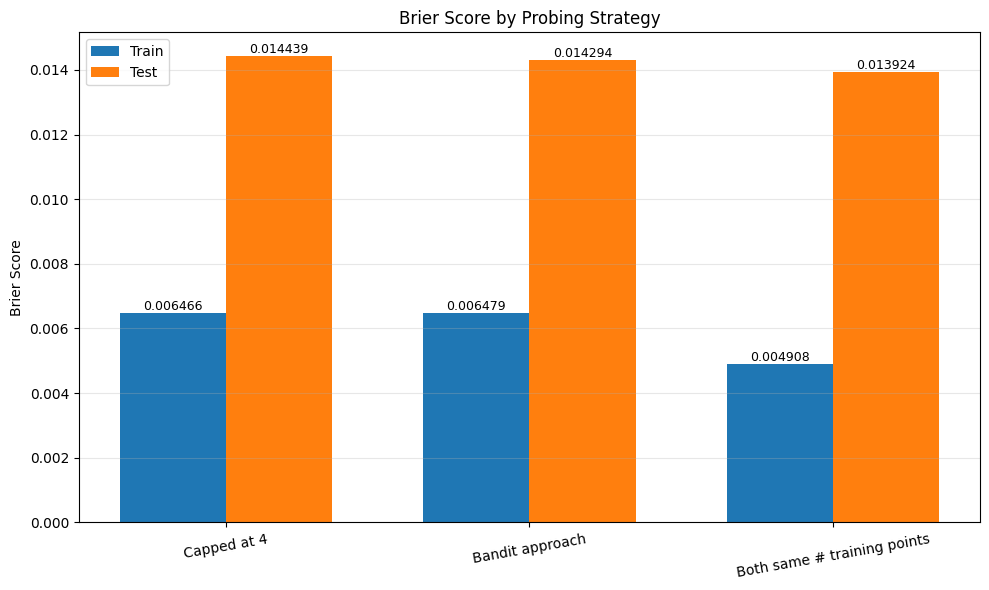

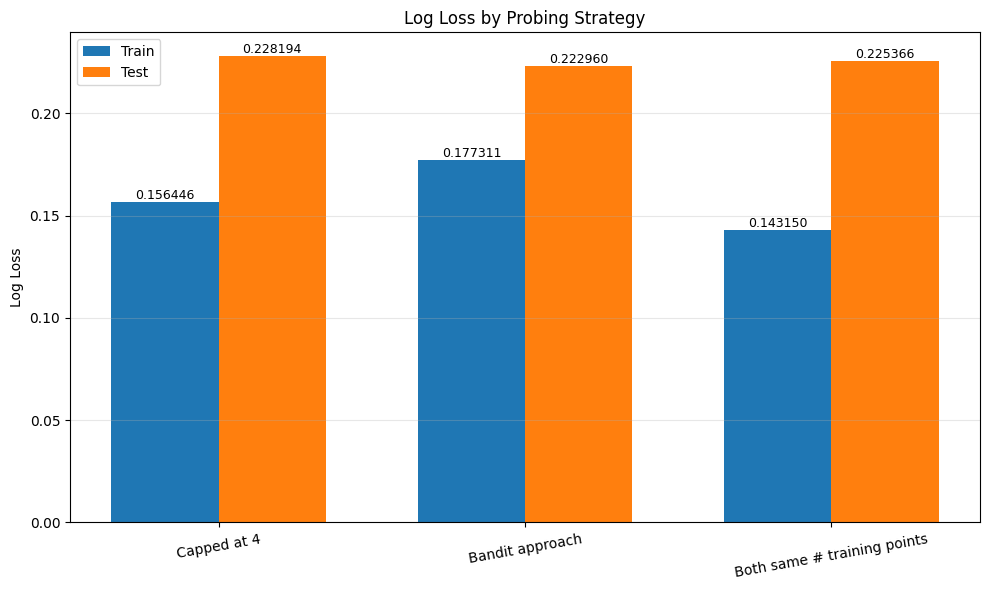

In [12]:
# -----------------------------
# Plot using the computed results
# -----------------------------
strategies = comparison_df["strategy"].tolist()

brier_train = comparison_df["brier_train"].tolist()
brier_test  = comparison_df["brier_test"].tolist()

logloss_train = comparison_df["logloss_train"].tolist()
logloss_test  = comparison_df["logloss_test"].tolist()

x = np.arange(len(strategies))
width = 0.35

# -----------------------------
# Chart 1: Brier Score
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, brier_train, width, label='Train')
bars2 = ax.bar(x + width/2, brier_test, width, label='Test')

ax.set_title("Brier Score by Probing Strategy")
ax.set_ylabel("Brier Score")
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=10)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.6f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

# -----------------------------
# Chart 2: Log Loss
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, logloss_train, width, label='Train')
bars2 = ax.bar(x + width/2, logloss_test, width, label='Test')

ax.set_title("Log Loss by Probing Strategy")
ax.set_ylabel("Log Loss")
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=10)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.6f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()